In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path

In [2]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib import font_manager
from pandas.api.types import CategoricalDtype
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['xtick.major.size'] = 3
mpl.rcParams['ytick.major.size'] = 3

# Figure 3A

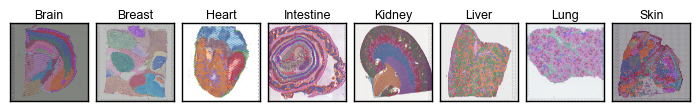

In [5]:
width_inch = 18 / 2.54
height_inch = 3 / 2.54
fig, axes = plt.subplots(1, 8, figsize=(width_inch, height_inch), sharey=False)
data_dic = {'Mouse_Brain': 'Section_Coronal',
            'Human_Breast_Cancer': 'Block_A_Section1',
            'Chicken_Heart': 'D14',
            'Mouse_Intestine': 'B1S2',
            'Adult_Mouse_Kidney': 'FFPE',
            'Mouse_Liver': 'GSM5764420',
            'Human_Lung': '6332STDY9479168',
            'Squamous_Cell_Carcinoma':'V10F24-015_A1'}
tissue_dic = {'Mouse_Brain':'Brain',
              'Human_Breast_Cancer':'Breast',
              'Chicken_Heart':'Heart',
              'Mouse_Intestine':'Intestine',
              'Adult_Mouse_Kidney':'Kidney',
              'Mouse_Liver':'Liver',
              'Human_Lung':'Lung',
              'Squamous_Cell_Carcinoma':'Skin'}
row = 0
col = 0
for col, (dataset, sample) in enumerate(data_dic.items()):

    h5ad_path = f"dataset/10x_Visium/{dataset}_{sample}_data.h5ad"
    adata = sc.read(h5ad_path)
    if dataset == 'Chicken_Heart':
        sc.pl.spatial(adata, color=['ground_truth'], show=False, ax=axes[col], legend_loc=None, size=4)
        axes[col].invert_yaxis()
    else:
        sc.pl.spatial(adata, color=['ground_truth'], show=False, ax=axes[col], legend_loc=None)
    axes[col].set_title(tissue_dic[dataset], fontsize=9, pad=3)
    axes[col].set_box_aspect(1)
    axes[col].set_xlabel('') 
    axes[col].set_ylabel('') 
    col += 1
plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
#plt.savefig("Figure3A.pdf")
plt.show()

# Figure 3B

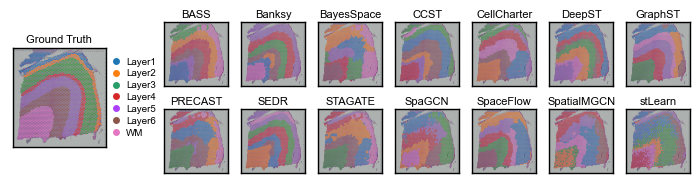

In [6]:
width_inch = 18 / 2.54
height_inch = 2.4 / 2.54
fig, axes = plt.subplots(2, 9, figsize=(width_inch, height_inch*2), sharey=False)

dataset = 'DLPFC'
sample = '151676'
Methods = ['BASS', 'Banksy', 'BayesSpace', 'CCST', 'CellCharter', 'DeepST', 'GraphST', 'PRECAST', 'SEDR', 'STAGATE', 'SpaGCN', 'SpaceFlow', 'SpatialMGCN', 'stLearn']
for row in range(2):
    for col in range(2):
        axes[row, col].remove()
big_ax = plt.subplot2grid((2, 9), (0, 0), rowspan=2, colspan=2)
data_dir = "dataset/10x_Visium/"
result_dir = f"Outputs/10X/"
raw_adata = sc.read(f"{data_dir}/{dataset}_{sample}_data.h5ad")
adata = raw_adata.copy()
inset_ax = big_ax.inset_axes([0, 0.15, 0.7, 0.7])
sc.pl.spatial(adata, color=['ground_truth'], show=False, ax=inset_ax, legend_loc=None)
inset_ax.set_xlabel('')
inset_ax.set_ylabel('')
inset_ax.set_title('Ground Truth', fontsize=8, pad=4)
import matplotlib.patches as mpatches
from scanpy.pl.palettes import default_20 
from matplotlib.lines import Line2D
labels = adata.obs['ground_truth'].astype(str).unique()
labels = sorted(labels)
colors = {label: default_20[i % len(default_20)] for i, label in enumerate(labels)}
legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[label],
           markeredgecolor='none', markersize=5, label=label)
    for label in labels
]
big_ax.legend(handles=legend_elements,loc='center left',bbox_to_anchor=(0.65, 0.5),ncol=1,frameon=False,fontsize=7,title_fontsize=7,labelspacing=0.3,handletextpad=0.01,borderpad=0.01)
big_ax.set_box_aspect(1)
big_ax.set_xlabel('')
big_ax.set_ylabel('')
big_ax.set_title('')
big_ax.set_xticks([])
big_ax.set_yticks([])
for spine in big_ax.spines.values():
    spine.set_visible(False)
for row in range(2):
    for col in range(2, 9):  
        if (row * 7 + (col - 2)) > 13:
            break
        method_index = row * 7 + (col - 2)
        method = Methods[method_index]       
        result_obs = pd.read_csv(f"{result_dir}/rep_1/{dataset}_{sample}_{method}_obs.csv", index_col=0)
        adata = raw_adata.copy()
        adata.obs = adata.obs.join(result_obs[['predict_cluster']], how='left')
        adata = adata[~pd.isnull(adata.obs['predict_cluster'])]
        adata.obs['predict_cluster'] = adata.obs['predict_cluster'].astype('category') 
        ax = axes[row, col]
        sc.pl.spatial(
            adata,
            color='predict_cluster',
            show=False,
            ax=ax,
            legend_loc=None
        )
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_box_aspect(1)
        ax.set_title(method, fontsize=8, pad=3)
plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05, wspace=0.2, hspace=0.05)
#plt.savefig("Figure3B.pdf")
plt.show()

# Figure 3C

In [8]:
df_10x_mean

,Technology,Dataset,Sample,Method,Tissue,ARI,NMI,FMI,Purity,Homogeneity,Completeness,V_measure,Time,Memory,PAS,CHAOS,ASW
14,10X,Chicken Heart,D10,BASS,Heart,0.443479,0.586776,0.540475,0.669624,0.583450,0.590141,0.586776,1322.425806,1349.680000,0.051670,0.065005,-0.022660
15,10X,Chicken Heart,D10,Banksy,Heart,0.496203,0.571187,0.590495,0.707516,0.561422,0.581415,0.571187,9.278539,328.487408,0.079019,0.067152,-0.084802
16,10X,Chicken Heart,D10,BayesSpace,Heart,0.610147,0.649608,0.680548,0.801148,0.638590,0.661013,0.649608,954.576010,4129.580000,0.110647,0.065894,-0.044825
17,10X,Chicken Heart,D10,CCST,Heart,0.340463,0.477665,0.461406,0.598017,0.468991,0.486804,0.477665,130.267015,458.953518,0.044259,0.064975,0.029897
18,10X,Chicken Heart,D10,CellCharter,Heart,0.372152,0.497802,0.477820,0.613257,0.501000,0.494705,0.497802,177.298266,161.840888,0.120355,0.067066,-0.041174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2094,10X,Mouse Liver,GSM5764422,STAGATE,Liver,0.222923,0.312837,0.495337,0.619457,0.321739,0.304842,0.312837,31.076580,721.008974,0.157692,0.075646,0.019753
2095,10X,Mouse Liver,GSM5764422,SpaGCN,Liver,0.164019,0.253200,0.410987,0.556561,0.280694,0.230612,0.253200,32.999306,1181.745275,0.215498,0.076947,-0.006751
2096,10X,Mouse Liver,GSM5764422,SpaceFlow,Liver,0.087792,0.124240,0.363138,0.510860,0.136922,0.113719,0.124240,21.424883,835.953960,0.065045,0.073743,0.050388
2097,10X,Mouse Liver,GSM5764422,SpatialMGCN,Liver,0.053995,0.120932,0.370676,0.512443,0.125260,0.116893,0.120932,36.079961,890.888231,0.068439,0.074075,0.032683


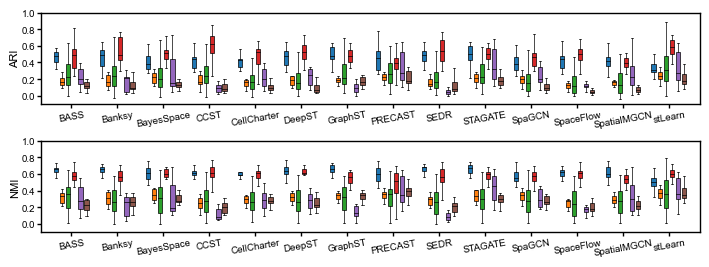

In [9]:
methods = sorted(list(set(df_10x_mean['Method'])))
tissues = ["Brain", "Breast", "Heart", "Intestine", "Liver", "Lung", "Kidney", "Skin"]
metrics = ['ARI', 'NMI']
tissue_order = ["Brain", "Breast", "Heart", "Intestine", "Liver", "Lung"]
df_10x_mean['Tissue'] = pd.Categorical(df_10x_mean['Tissue'], categories=tissue_order, ordered=True)
method_order = ['Banksy', 'BASS', 'BayesSpace', 'CCST', 'CellCharter', 'DeepST', 'GraphST', 'PRECAST', 'SEDR', 'SpaceFlow', 'SpaGCN', 'SpatialMGCN', 'STAGATE', 'stLearn']
df_10x_mean['Method'] = pd.Categorical(df_10x_mean['Method'], categories=method_order, ordered=True)
method_colors = {
    "Brain": "#1F77B4", 
    "Breast": "#FF7F0E",
    "Heart": "#2CA02C",
    "Intestine": "#D62728",
    "Liver": "#9467BD",
    "Lung": "#8C564B",
    "Kidney": "#E377C2",
    "Skin": "#7F7F7F"
}
width_inch = 18 / 2.54
height_inch = 3 / 2.54
fig, axes = plt.subplots(2, 1, figsize=(width_inch, 2 * height_inch), sharey=False)
box_width = 0.14
gap = 0.06
method_spacing = 1.5  
method_positions = np.arange(len(methods)) * method_spacing

for ax, metric in zip(axes, metrics):
    for i, tissue in enumerate(tissue_order):
        offset = (i - (len(tissue_order) - 1) / 2) * (box_width + gap)
        for j, method in enumerate(methods):
            subset = df_10x_mean[(df_10x_mean['Method'] == method) & (df_10x_mean['Tissue'] == tissue)][metric]
            position = method_positions[j] + offset
            bplot = ax.boxplot(subset,
                               positions=[position],
                               widths=box_width,
                               patch_artist=True,
                               showfliers=False,
                               boxprops=dict(facecolor=method_colors[tissue], linewidth=0.5),
                               medianprops=dict(color='black', linewidth=0.5),
                               whiskerprops=dict(linewidth=0.5),
                               capprops=dict(linewidth=0.5)
                              )

    ax.set_xticks(method_positions)
    ax.set_xticklabels(methods, rotation=10, fontsize=7, color='black')
    ax.set_ylabel(metric, fontsize=8, labelpad=1, color='black')
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_ylim(-0.1, 1)
    ax.tick_params(axis='both', which='both', labelsize=7, pad=1, length=3, width=1, color='black', labelcolor='black')
    ax.grid(False)
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1)
        ax.spines[spine].set_color('black')
plt.subplots_adjust(left=0.05, right=0.98, top=0.98, bottom=0.05, hspace=0.4)
#plt.savefig("Figure3C.pdf")
plt.show()

# Figure 3D

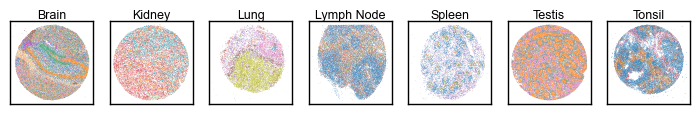

In [11]:
width_inch = 18 / 2.54
height_inch = 3 / 2.54
fig, axes = plt.subplots(1, 7, figsize=(width_inch, height_inch), sharey=False)
data_dic = {'Brain': 'Mouse_Cortex_data',
            'Human Normal': 'Puck_200104_21',
            'Human Lung': 'Puck_200727_09',
            'Human Lymph Node': 'Puck_201014_06',
            'Mouse Spleen': 'Puck_200727_02',
            'mammalian spermatogenesis': 'WT3_data',
            'Human Tonsil':'Puck_210119_22'}
tissue_dic = {'Brain':'Brain',
              'Human Normal':'Kidney',
              'Human Lung':'Lung',
              'Human Lymph Node':'Lymph Node',
              'Mouse Spleen':'Spleen',
              'mammalian spermatogenesis':'Testis',
              'Human Tonsil':'Tonsil'}
row = 0
col = 0
for col, (dataset, sample) in enumerate(data_dic.items()):
    h5ad_path = f"dataset/Slideseq/{dataset}/{sample}.h5ad"
    adata = sc.read(h5ad_path)
    sc.pl.embedding(adata, basis='spatial', color=['ground_truth'], show=False, ax=axes[col], legend_loc=None, size=0.3)
    axes[col].set_title(tissue_dic[dataset], fontsize=9, color='black', pad=2)
    axes[col].set_box_aspect(1)
    axes[col].set_xlabel('') 
    axes[col].set_ylabel('') 
    for spine in axes[col].spines.values():
        spine.set_linewidth(1)
        spine.set_color('black')
    col += 1
plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05, wspace=0.2, hspace=0.1)
#plt.savefig("Figure3D.pdf")
plt.show()

# Figure 3E

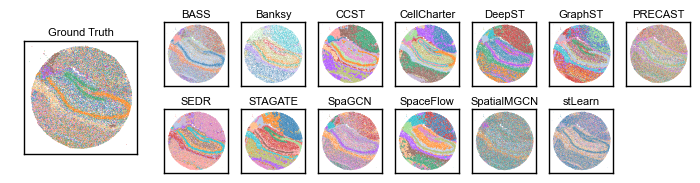

In [16]:
width_inch = 18 / 2.54
height_inch = 2.4 / 2.54
fig, axes = plt.subplots(2, 9, figsize=(width_inch, height_inch*2), sharey=False)

dataset = 'Brain'
sample = 'Mouse_Cortex_data'
Methods = ['BASS', 'Banksy', 'CCST', 'CellCharter', 'DeepST', 'GraphST', 'PRECAST', 'SEDR', 'STAGATE', 'SpaGCN', 'SpaceFlow', 'SpatialMGCN', 'stLearn']
for row in range(2):
    for col in range(2):
        axes[row, col].remove()
big_ax = plt.subplot2grid((2, 9), (0, 0), rowspan=2, colspan=2)
data_dir = "dataset/Slideseq/process/"
result_dir = f"Outputs/Slideseq/"
raw_adata = sc.read(f"{data_dir}/{dataset}/{sample}.h5ad")
adata = raw_adata.copy()
inset_ax = big_ax.inset_axes([0.1, 0.1, 0.8, 0.8])
sc.pl.embedding(adata, basis='spatial', color=['ground_truth'], show=False, ax=inset_ax, legend_loc=None, size=0.6)
inset_ax.set_xlabel('')
inset_ax.set_ylabel('')
inset_ax.set_title('Ground Truth', fontsize=8, pad=4)
import matplotlib.patches as mpatches
from scanpy.pl.palettes import default_20 
from matplotlib.lines import Line2D
labels = adata.obs['ground_truth'].astype(str).unique()
labels = sorted(labels)
colors = {label: default_20[i % len(default_20)] for i, label in enumerate(labels)}
legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[label],
           markeredgecolor='none', markersize=5, label=label)
    for label in labels
]
big_ax.set_box_aspect(1)
big_ax.set_xlabel('')
big_ax.set_ylabel('')
big_ax.set_title('')
big_ax.set_xticks([])
big_ax.set_yticks([])
for spine in big_ax.spines.values():
    spine.set_visible(False)

for row in range(2):
    for col in range(2, 9):  
        if (row * 7 + (col - 2)) > 12:
            break
        method_index = row * 7 + (col - 2)
        method = Methods[method_index]
   
        result_obs = pd.read_csv(f"{result_dir}/{dataset}_{sample}_{method}_obs.csv", index_col=0)
        adata = raw_adata.copy()
        adata.obs = adata.obs.join(result_obs[['predict_cluster']], how='left')
        adata = adata[~pd.isnull(adata.obs['predict_cluster'])]
        adata.obs['predict_cluster'] = adata.obs['predict_cluster'].astype('category') 
        ax = axes[row, col]
        sc.pl.embedding(
            adata,
            basis='spatial',
            color='predict_cluster',
            show=False,
            ax=ax,
            legend_loc=None,
            size=0.2
        )
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_box_aspect(1)
        ax.set_title(method, fontsize=8, pad=3)
for ax_row in axes:
    for ax in ax_row:
        if ax and not ax.has_data():
            try:
                ax.remove() 
            except KeyError:
                pass
plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05, wspace=0.2, hspace=0.05)
plt.savefig("Figure3E.pdf")
plt.show()

# Figure 3F

In [ ]:
df_Slideseq_mean = pd.read_csv("df_Slideseq.csv", index_col=0)
df_short = df_Slideseq_mean.copy()

In [18]:
df_short

,Tech,Dataset,Sample,Method,Tissue,ARI,NMI,FMI,Purity,Homogeneity,Completeness,V_measure,Memory,Time
0,Slideseq,mammalian spermatogenesis,Diabetes_1_data,BASS,Testis,0.223091,0.260808,0.357728,0.561594,0.285761,0.239864,0.260808,8410.800000,2952.389293
1,Slideseq,mammalian spermatogenesis,Diabetes_1_data,Banksy,Testis,0.217318,0.263911,0.371881,0.587902,0.269241,0.259002,0.263911,3978.959082,67.030978
2,Slideseq,mammalian spermatogenesis,Diabetes_1_data,CCST,Testis,0.110490,0.156132,0.261916,0.503971,0.169506,0.144714,0.156132,22111.172211,6723.953587
3,Slideseq,mammalian spermatogenesis,Diabetes_1_data,CellCharter,Testis,0.106087,0.163608,0.251798,0.486725,0.181682,0.148806,0.163608,835.633576,1577.254756
4,Slideseq,mammalian spermatogenesis,Diabetes_1_data,DeepST,Testis,0.093024,0.205687,0.301115,0.481930,0.194216,0.218944,0.205687,31457.677260,733.184028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1360,Slideseq,Mouse Spleen,Puck_200727_025,STAGATE,Spleen,0.178607,0.215044,0.407663,0.641095,0.259535,0.183574,0.215044,173.240385,104.990483
1361,Slideseq,Mouse Spleen,Puck_200727_025,SpaGCN,Spleen,0.129515,0.183046,0.360109,0.615725,0.225043,0.154258,0.183046,3264.465033,424.723775
1362,Slideseq,Mouse Spleen,Puck_200727_025,SpaceFlow,Spleen,0.116398,0.158806,0.355801,0.600869,0.193390,0.134715,0.158806,376.435354,221.183550
1363,Slideseq,Mouse Spleen,Puck_200727_025,SpatialMGCN,Spleen,0.153088,0.185310,0.382033,0.617724,0.226885,0.156612,0.185310,1686.887336,99.691023


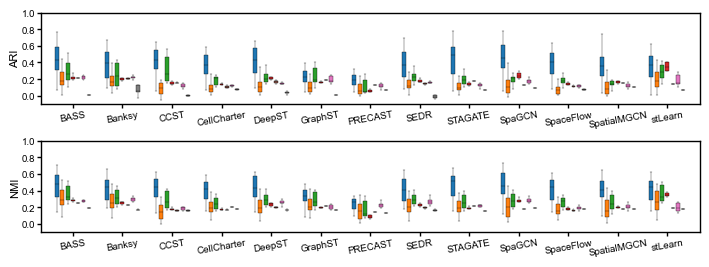

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as mpl

methods = sorted(list(set(df_short['Method'])))
tissues = ["Brain", "Kidney", "Lung", "Lymph Node", "Spleen", "Testis", "Tonsil"]
metrics = ['ARI', 'NMI']
tissue_order = ["Brain", "Kidney", "Lung", "Lymph Node", "Spleen", "Testis", "Tonsil"]
df_short['Tissue'] = pd.Categorical(df_short['Tissue'], categories=tissue_order, ordered=True)
method_order = ['Banksy', 'BASS', 'CCST', 'CellCharter', 'DeepST', 'GraphST', 'PRECAST', 'SEDR', 'SpaceFlow', 'SpaGCN', 'SpatialMGCN', 'STAGATE', 'stLearn']
df_short['Method'] = pd.Categorical(df_short['Method'], categories=method_order, ordered=True)

method_colors = {
    "Brain": "#1F77B4", 
    "Kidney": "#FF7F0E",
    "Lung": "#2CA02C",
    "Lymph Node": "#D62728",
    "Spleen": "#8C564B",
    "Testis": "#E377C2",
    "Tonsil": "#7F7F7F"
}

sns.set(style="ticks") 
width_inch = 18 / 2.54
height_inch = 3 / 2.54
fig, axes = plt.subplots(2, 1, figsize=(width_inch, 2 * height_inch), sharey=False)
box_width = 0.12
gap = 0.04
method_spacing = 1.5  
method_positions = np.arange(len(methods)) * method_spacing

for ax, metric in zip(axes, metrics):
    for i, tissue in enumerate(tissue_order):
        offset = (i - (len(tissue_order) - 1) / 2) * (box_width + gap)
        for j, method in enumerate(methods):
            subset = df_short[(df_short['Method'] == method) & (df_short['Tissue'] == tissue)][metric]
            position = method_positions[j] + offset
            bplot = ax.boxplot(subset,
                               positions=[position],
                               widths=box_width,
                               patch_artist=True,
                               showfliers=False,
                               boxprops=dict(facecolor=method_colors[tissue], linewidth=0.25),
                               medianprops=dict(color='black', linewidth=0.25),
                               whiskerprops=dict(linewidth=0.25),
                               capprops=dict(linewidth=0.25)
                              )

    ax.set_xticks(method_positions)
    ax.set_xticklabels(methods, rotation=10, fontsize=7, color='black')
    ax.set_ylabel(metric, fontsize=8, labelpad=1, color='black')
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_ylim(-0.1, 1)
    ax.tick_params(axis='both', which='both', labelsize=7, pad=1, length=3, width=1, color='black', labelcolor='black')
    ax.grid(False)
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1)
        ax.spines[spine].set_color('black')
plt.subplots_adjust(left=0.05, right=0.98, top=0.98, bottom=0.05, hspace=0.4)
plt.savefig("Figure3F.pdf")
plt.show()